Installayion IA-SVI:

```R
    if (!requireNamespace("BiocManager", quietly = TRUE))
        install.packages("BiocManager")
    
    BiocManager::install("iasva")

```



# Hyperparameters

In [1]:
%load_ext autoreload
%autoreload 2



import pandas as pd
import numpy as np
from scipy import sparse
import scanpy as sc
import matplotlib.pyplot as plt
import os
import rpy2.robjects as ro

from dotenv import load_dotenv; load_dotenv()


from utils import preprocessing
from utils import DEG

# ATTENTION: need for perpty of running jupternotbook
%matplotlib inline

GRADIENT_GENES_CORR_PATH = os.getenv("GRADIENT_GENES_CORR_PATH")
PARALLEL_NEBULA_SCRIPT_PATH = os.getenv("PARALLEL_NEBULA_SCRIPT")


ADATA_PATH = f"/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_001/depleted_versions/depleted_0.50_dorsal_matrix/depleted_0.50_dorsal_matrix.h5ad"
adata_path_name=f"{os.path.split(ADATA_PATH)[1].split('.')[0]}"
ADATA_PATH_BASE = os.path.splitext(ADATA_PATH)[0]
ADATA_FOLDER = os.path.dirname(ADATA_PATH)
SAVE_FOLDER = f"/home/gdallagl/myworkdir/XDP/data/artificial_DEG_analysis/IA-SVI/{adata_path_name}"
TRUE_DEG_PATH = f"{ADATA_FOLDER}/genes.csv"
QS_TMP_FOLDER = "/home/gdallagl/myworkdir/XDP/data/_old/nebula_tmp" # tmp folder where to save intemrediate results
#os.makedirs(SAVE_FOLDER, exist_ok=True)

# name of cell tyoe vauble annotaton to use in this analsys
CT_FOR_DEG_VARIABLE = "spn_type" #"Group_name",  "spn_type"
# name of Sample varibale
SAMPLE_VARIABLE = "donor_id"
# variable to test if differtially epxressed
CONTRAST_VARIABLE = "case_control"
# Level of contrat varibale to use as baseline
CONTRAST_BASELINE = "control"
# Level of contrat varibale to use as stimulated
CONTRAST_STIM = "case"

# Covariates to use for stat test
COVARIATES_FOR_DEG = ["Age.at.Death", "Sex", "PMI", "pct_mt", "pct_intronic",
                      ]
# libraru size col for  enbula
LIBRARY_SIZE_COL = "nCount_RNA"

# mitluple etst correction pvalue thr
ALPHA_MULTIPLE_TEST = 0.05
LOGFC_THR=0.1
PVAL_THR=0.05

# Read adata

In [2]:
adata = sc.read_h5ad(
    #"/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/original_data/NucSeq_all_labelled_zoned.h5ad", 
    ADATA_PATH,
    #backed="r"
    )

#adata = adata[adata.obs.spn_type == "espn"].to_memory().copy()


adata

AnnData object with n_obs × n_vars = 93578 × 37905
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'donor_id', 'PREFIX', 'CELL_BARCODE', 'NUM_GENIC_READS', 'NUM_TRANSCRIPTS', 'NUM_GENES', 'num_retained_transcripts', 'pct_coding', 'pct_utr', 'pct_intergenic', 'pct_genic', 'pct_intronic', 'pct_mt', 'pct_ribosomal', 'frac_contamination', 'experiment', 'Neighborhood_name', 'Neighborhood_bootstrapping_probability', 'Class_name', 'Class_bootstrapping_probability', 'Subclass_name', 'Subclass_bootstrapping_probability', 'Group_name', 'Group_bootstrapping_probability', 'Cluster_name', 'Cluster_alias', 'Cluster_bootstrapping_probability', 'x', 'y', 'library', 'donor', 'x_um2', 'y_um2', 'unique_cell_ID', 'cb', 'Final_Zone_Assignments', 'Group_name.1', 'cell_type', 'Cohort', 'Biobank', 'Age.at.Death', 'Sex', 'Race', 'Ethnicity', 'Cause.of.Death', 'PMI', 'spn_type', 'case_control', 'RNA_snn_res.0.2', 'seurat_clusters', 'RNA_snn_res.0.5', 'Row.names', 'PC_1', 'PC_2', 'PC_3', 'PC_4', 'PC_5', 'PC

In [ ]:

# 2. Filter lowly expressed genes
sc.pp.filter_genes(adata, min_cells=10)

# 3. Calculate geometric library size (for covariates)
print("Calculating geometric library size...")
if sparse.issparse(adata.X):
    geo_lib_size = np.array(np.sum(np.log1p(adata.X.toarray()), axis=1)).flatten()
else:
    geo_lib_size = np.sum(np.log1p(adata.X), axis=1)

adata.obs['geo_lib_size'] = geo_lib_size

# 4. Get RAW counts
print("Getting raw counts matrix...")
Y = adata.X
if sparse.issparse(Y):
    Y = Y.toarray()

# 5. Create design matrix (include geo_lib_size as covariate)
from patsy import dmatrix
formula = "donor_id + Q('Age.at.Death') + Sex + PMI + pct_mt + pct_intronic + geo_lib_size"
X_df = dmatrix(f"~ {formula} - 1", data=adata.obs, return_type="dataframe")
X = X_df.values

NameError: name 'dmatrix' is not defined

In [4]:
import torch
import numpy as np
from scipy import sparse
from scipy.sparse.linalg import svds
import gc

class IASVA_MemoryEfficient:
    """
    Ultra memory-efficient IA-SVA with aggressive chunking
    Processes large matrices without loading everything into RAM
    """
    
    def __init__(self, device='cuda', gene_batch_size=500, cell_batch_size=2000):
        self.device = torch.device(device if torch.cuda.is_available() else 'cpu')
        self.gene_batch_size = gene_batch_size  # Process genes in batches
        self.cell_batch_size = cell_batch_size  # For log-transform
        print(f"Device: {self.device}")
        print(f"Gene batch: {gene_batch_size}, Cell batch: {cell_batch_size}")
    
    def fit(self, Y, X, num_sv=5, intercept=True, verbose=True):
        """
        Y: RAW COUNTS (scipy sparse matrix or numpy array)
        X: Design matrix (numpy array)
        """
        n_cells, n_genes = Y.shape
        
        if verbose:
            print(f"\nData: {n_cells} cells x {n_genes} genes")
            print(f"Memory-efficient mode with chunking")
        
        is_sparse = sparse.issparse(Y)
        
        # Ensure non-negative (in-place for sparse)
        if is_sparse:
            if Y.data.min() < 0:
                Y.data += abs(Y.data.min())
        else:
            if Y.min() < 0:
                Y += abs(Y.min())
        
        # DON'T convert all to dense - process in chunks
        if verbose:
            print("Processing in memory-efficient chunks...")
        
        # Collect SVs
        all_svs = []
        X_current = X.copy()
        
        for sv_idx in range(num_sv):
            if verbose:
                print(f"\n{'='*60}")
                print(f"Computing SV {sv_idx + 1}/{num_sv}")
                print(f"{'='*60}")
            
            sv = self._iasva_unit_efficient(Y, X_current, is_sparse, intercept, verbose)
            all_svs.append(sv)
            
            # Add to design matrix
            X_current = np.column_stack([X_current, sv])
            
            # Aggressive memory cleanup
            gc.collect()
            if self.device.type == 'cuda':
                torch.cuda.empty_cache()
        
        self.sv_matrix = np.column_stack(all_svs)
        return self.sv_matrix
    
    def _iasva_unit_efficient(self, Y, X, is_sparse, intercept, verbose):
        """
        Process one SV iteration with minimal memory
        """
        n_cells, n_genes = Y.shape
        
        # Build design matrix
        if intercept:
            X_full = np.column_stack([np.ones(n_cells, dtype=np.float32), X])
        else:
            X_full = X
        
        # Precompute QR decomposition ONCE (reuse for all batches)
        if verbose:
            print("  Computing QR decomposition...")
        Q, R = np.linalg.qr(X_full)
        QtQ = Q @ Q.T
        
        # Step 1: Residualize in chunks (avoid loading all genes at once)
        if verbose:
            print("  Residualizing in batches...")
        
        residuals_file = self._residualize_chunked(Y, QtQ, is_sparse, verbose)
        
        # Step 2: Compute PC1 from residuals (chunked SVD)
        if verbose:
            print("  Computing PC1 via truncated SVD...")
        
        pc1 = self._compute_pc1_chunked(residuals_file, n_cells, n_genes, verbose)
        
        # Step 3: Compute R² per gene (in batches)
        if verbose:
            print("  Computing R² per gene...")
        
        rsq_vec = self._compute_rsq_chunked(residuals_file, pc1, n_genes, verbose)
        
        # Step 4: Normalize to weights
        rsq_vec[np.isnan(rsq_vec)] = np.nanmin(rsq_vec)
        wgt = (rsq_vec - rsq_vec.min()) / (rsq_vec.max() - rsq_vec.min() + 1e-10)
        
        # Step 5: Final weighted SVD (chunked)
        if verbose:
            print("  Final weighted SVD...")
        
        sv = self._final_svd_chunked(Y, wgt, is_sparse, verbose)
        
        # Cleanup
        del residuals_file, pc1, rsq_vec, wgt
        gc.collect()
        
        return sv
    
    def _residualize_chunked(self, Y, QtQ, is_sparse, verbose):
        """
        Residualize in batches, save to memory-mapped file or process incrementally
        Returns: numpy memmap array for residuals
        """
        n_cells, n_genes = Y.shape
        
        # Create temporary memmap file for residuals (avoid keeping in RAM)
        import tempfile
        temp_file = tempfile.NamedTemporaryFile(delete=False, suffix='.dat')
        residuals = np.memmap(temp_file.name, dtype='float32', mode='w+', 
                             shape=(n_cells, n_genes))
        
        n_batches = int(np.ceil(n_genes / self.gene_batch_size))
        
        for batch_idx in range(n_batches):
            start = batch_idx * self.gene_batch_size
            end = min(start + self.gene_batch_size, n_genes)
            
            if verbose and batch_idx % 10 == 0:
                print(f"    Batch {batch_idx+1}/{n_batches} ({start}-{end})")
            
            # Load batch
            if is_sparse:
                Y_batch = Y[:, start:end].toarray()
            else:
                Y_batch = Y[:, start:end]
            
            # Log-transform
            lY_batch = np.log(Y_batch + 1).astype(np.float32)
            
            # Residualize: resid = lY - Q @ Q^T @ lY
            lY_pred = QtQ @ lY_batch
            resid_batch = lY_batch - lY_pred
            
            # Save to memmap
            residuals[:, start:end] = resid_batch
            
            # Cleanup
            del Y_batch, lY_batch, lY_pred, resid_batch
        
        residuals.flush()
        return residuals
    
    def _compute_pc1_chunked(self, residuals, n_cells, n_genes, verbose):
        """
        Compute first principal component using randomized SVD
        """
        # Transpose: genes x cells
        # Use randomized SVD for memory efficiency
        from sklearn.utils.extmath import randomized_svd
        
        # Process in chunks to compute covariance incrementally
        # For very large matrices, use approximate methods
        
        if n_genes < 50000:
            # Can load into memory for SVD
            tresid = residuals.T.copy()  # genes x cells
            row_means = tresid.mean(axis=1, keepdims=True)
            tresid_centered = tresid - row_means
            
            # Truncated SVD (k=1)
            try:
                u, s, vh = svds(tresid_centered, k=1, which='LM')
                pc1 = vh[0, :]
            except:
                # Fallback: randomized SVD
                u, s, vh = randomized_svd(tresid_centered, n_components=1, 
                                         n_iter=5, random_state=42)
                pc1 = vh[0, :]
            
            del tresid, tresid_centered
        else:
            # For very large: use incremental PCA or randomized method
            from sklearn.decomposition import IncrementalPCA
            
            ipca = IncrementalPCA(n_components=1, batch_size=self.gene_batch_size)
            
            # Fit in batches (transpose on-the-fly)
            n_batches = int(np.ceil(n_genes / self.gene_batch_size))
            for batch_idx in range(n_batches):
                start = batch_idx * self.gene_batch_size
                end = min(start + self.gene_batch_size, n_genes)
                
                batch = residuals[:, start:end].T  # Transpose: batch_genes x cells
                batch_centered = batch - batch.mean(axis=1, keepdims=True)
                ipca.partial_fit(batch_centered.T)  # Fit on cells
                
                del batch, batch_centered
            
            # Transform to get PC1
            pc1 = ipca.components_[0, :]
        
        gc.collect()
        return pc1
    
    def _compute_rsq_chunked(self, residuals, pc1, n_genes, verbose):
        """
        Compute R² in batches on GPU
        """
        n_cells = residuals.shape[0]
        rsq_vec = np.zeros(n_genes, dtype=np.float32)
        
        # Move PC1 to GPU once
        pc1_gpu = torch.tensor(pc1, dtype=torch.float32, device=self.device)
        ones_gpu = torch.ones((n_cells, 1), dtype=torch.float32, device=self.device)
        X_pc1 = torch.cat([ones_gpu, pc1_gpu.unsqueeze(1)], dim=1)
        
        # Precompute QR once
        Q, R = torch.linalg.qr(X_pc1)
        
        n_batches = int(np.ceil(n_genes / self.gene_batch_size))
        
        for batch_idx in range(n_batches):
            start = batch_idx * self.gene_batch_size
            end = min(start + self.gene_batch_size, n_genes)
            
            if verbose and batch_idx % 20 == 0:
                print(f"    R² batch {batch_idx+1}/{n_batches}")
            
            # Load residuals batch
            resid_batch = residuals[:, start:end]
            resid_gpu = torch.tensor(resid_batch, dtype=torch.float32, device=self.device)
            
            # Compute R²
            resid_pred = Q @ (Q.T @ resid_gpu)
            new_resid = resid_gpu - resid_pred
            
            RSS = (new_resid ** 2).sum(dim=0)
            resid_centered = resid_gpu - resid_gpu.mean(dim=0, keepdim=True)
            TSS = (resid_centered ** 2).sum(dim=0)
            
            rsq_batch = 1 - (RSS / (n_cells - 2)) / (TSS / (n_cells - 1) + 1e-10)
            
            # Save
            rsq_vec[start:end] = rsq_batch.cpu().numpy()
            
            # Cleanup
            del resid_batch, resid_gpu, resid_pred, new_resid, RSS, TSS, rsq_batch
            if self.device.type == 'cuda':
                torch.cuda.empty_cache()
        
        del pc1_gpu, ones_gpu, X_pc1, Q, R
        gc.collect()
        
        return rsq_vec
    
    def _final_svd_chunked(self, Y, wgt, is_sparse, verbose):
        """
        Final SVD on weighted log-transformed data
        Process in chunks to avoid memory overflow
        """
        n_cells, n_genes = Y.shape
        
        # Build weighted matrix incrementally for SVD
        # Use memory-mapped array
        import tempfile
        temp_file = tempfile.NamedTemporaryFile(delete=False, suffix='.dat')
        weighted_lY = np.memmap(temp_file.name, dtype='float32', mode='w+',
                               shape=(n_genes, n_cells))  # Transposed!
        
        n_batches = int(np.ceil(n_genes / self.gene_batch_size))
        
        for batch_idx in range(n_batches):
            start = batch_idx * self.gene_batch_size
            end = min(start + self.gene_batch_size, n_genes)
            
            if verbose and batch_idx % 10 == 0:
                print(f"    Weighting batch {batch_idx+1}/{n_batches}")
            
            # Load and log-transform batch
            if is_sparse:
                Y_batch = Y[:, start:end].toarray()
            else:
                Y_batch = Y[:, start:end]
            
            lY_batch = np.log(Y_batch + 1).astype(np.float32)
            
            # Weight and transpose
            wgt_batch = wgt[start:end]
            tlY_batch = lY_batch.T * wgt_batch[:, np.newaxis]
            
            # Save
            weighted_lY[start:end, :] = tlY_batch
            
            del Y_batch, lY_batch, tlY_batch
        
        weighted_lY.flush()
        
        # SVD on weighted matrix
        if verbose:
            print("    Final truncated SVD...")
        
        # Center by row
        row_means = weighted_lY.mean(axis=1, keepdims=True)
        
        # For centering, process in chunks
        centered_weighted = np.memmap(temp_file.name + '_centered', dtype='float32',
                                     mode='w+', shape=(n_genes, n_cells))
        
        for i in range(0, n_genes, self.gene_batch_size):
            end = min(i + self.gene_batch_size, n_genes)
            centered_weighted[i:end, :] = weighted_lY[i:end, :] - row_means[i:end, :]
        
        centered_weighted.flush()
        
        # Truncated SVD
        try:
            u, s, vh = svds(centered_weighted, k=1, which='LM')
            sv = vh[0, :]
        except:
            # Fallback: randomized SVD
            from sklearn.utils.extmath import randomized_svd
            u, s, vh = randomized_svd(centered_weighted, n_components=1,
                                     n_iter=5, random_state=42)
            sv = vh[0, :]
        
        # Cleanup
        del weighted_lY, row_means, centered_weighted
        gc.collect()
        
        return sv


# ============================================================================
# USAGE
# ============================================================================

import scanpy as sc
import numpy as np
from scipy import sparse
from patsy import dmatrix

# Load data
# adata should contain RAW COUNTS

# Filter
sc.pp.filter_genes(adata, min_cells=10)

# Calculate geo_lib_size
if sparse.issparse(adata.X):
    # Process in chunks to avoid memory overflow
    geo_lib_size = []
    batch_size = 1000
    for i in range(0, adata.n_obs, batch_size):
        end = min(i + batch_size, adata.n_obs)
        batch = adata.X[i:end, :].toarray()
        geo_lib_size.append(np.sum(np.log1p(batch), axis=1))
    geo_lib_size = np.concatenate(geo_lib_size)
else:
    geo_lib_size = np.sum(np.log1p(adata.X), axis=1)

adata.obs['geo_lib_size'] = geo_lib_size

# Get RAW counts (keep as sparse!)
Y = adata.X  # Keep sparse if possible

# Design matrix
formula = "donor_id + geo_lib_size + pct_mt + pct_intronic"
X_df = dmatrix(f"~ {formula} - 1", data=adata.obs, return_type="dataframe")
X = X_df.values.astype(np.float32)  # Use float32 to save memory

print(f"Design matrix shape: {X.shape}")

# Run ultra-efficient IA-SVA
iasva = IASVA_MemoryEfficient(
    device='cuda',
    gene_batch_size=300,   # Reduce if still OOM
    cell_batch_size=1000
)

sv_matrix = iasva.fit(
    Y=Y,  # RAW COUNTS (can be sparse!)
    X=X,
    num_sv=1,
    intercept=True,
    verbose=True
)

# Add to adata
for i in range(sv_matrix.shape[1]):
    adata.obs[f'iaSV{i+1}'] = sv_matrix[:, i]

print(f"\nDone! SV matrix shape: {sv_matrix.shape}")

Design matrix shape: (93578, 22)
Device: cuda
Gene batch: 300, Cell batch: 1000

Data: 93578 cells x 35294 genes
Memory-efficient mode with chunking
Processing in memory-efficient chunks...

Computing SV 1/1
  Computing QR decomposition...
  Residualizing in batches...
    Batch 1/118 (0-300)
    Batch 11/118 (3000-3300)
    Batch 21/118 (6000-6300)
    Batch 31/118 (9000-9300)
    Batch 41/118 (12000-12300)
    Batch 51/118 (15000-15300)
    Batch 61/118 (18000-18300)
    Batch 71/118 (21000-21300)
    Batch 81/118 (24000-24300)
    Batch 91/118 (27000-27300)
    Batch 101/118 (30000-30300)
    Batch 111/118 (33000-33300)
  Computing PC1 via truncated SVD...
  Computing R² per gene...
    R² batch 1/118
    R² batch 21/118
    R² batch 41/118
    R² batch 61/118
    R² batch 81/118
    R² batch 101/118
  Final weighted SVD...
    Weighting batch 1/118
    Weighting batch 11/118
    Weighting batch 21/118
    Weighting batch 31/118
    Weighting batch 41/118
    Weighting batch 51/118


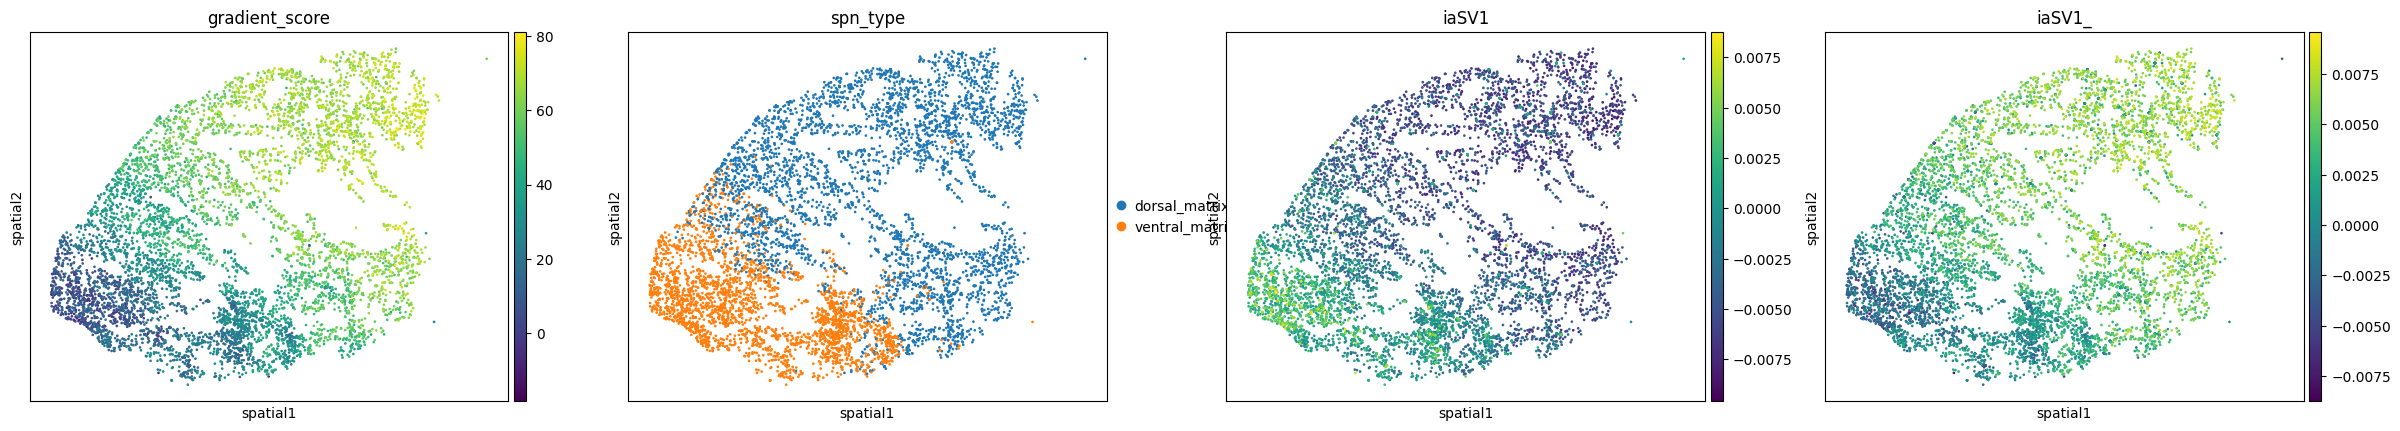

,gradient_score,iaSV1
gradient_score,1.000000,-0.817309
iaSV1,-0.817309,1.000000


In [14]:
adata_s = adata[adata.obs.donor_id == "PT13935"].to_memory().copy()
adata_s.obsm["spatial"] = adata_s.obs[["x", "y"]].values  # or .to_numpy()
adata_s.obs["iaSV1_"] = (-1) * adata_s.obs["iaSV1"]
sc.pl.embedding(adata_s, basis="spatial", color=["gradient_score", "spn_type", "iaSV1", "iaSV1_"])

adata_s.obs[["gradient_score", "iaSV1"]].corr()

# Make qs files

Specific for cell type (all samples together).

In [5]:
# Initialize X_umap if it doesn't exist
if 'X_umap' not in adata.obsm:
    adata.obsm['X_umap'] = np.full((adata.shape[0], 2), np.nan)

for ct in adata.obs[CT_FOR_DEG_VARIABLE].unique():

    ct="espn"

    sv_csv_path = os.path.join(SAVE_FOLDER, f"{ct.replace(' ', '_')}_SVs.csv")
    gene_corr_path = os.path.join(SAVE_FOLDER, f"{ct.replace(' ', '_')}_gene_SV_correlations.csv")
    saving_path = os.path.join(SAVE_FOLDER, f"{ct.replace(' ', '_')}.qs")

    # a = adata[adata.obs[CT_FOR_DEG_VARIABLE] == ct].copy()

    # print(ct,"\n", a)

    # #############################
    # # Normalise

    # print("\tBe sure that .X is raw counts")    

    # print("\tProcessing...")
    # # Filter lowly expressed
    # sc.pp.filter_genes(a, min_cells=10)
    # sc.pp.normalize_total(a, target_sum=1e4, inplace=True)
    # sc.pp.log1p(a)

    # #############################
    # # Save qs

    # print("\tSaving files for R coversion...")
    # preprocessing.save_files_for_R_conversion(a, QS_TMP_FOLDER)
    # print("\tBuilding R obj...")
    # preprocessing.build_qs_from_python_files(QS_TMP_FOLDER, saving_path=saving_path, contrast_var=CONTRAST_VARIABLE, reference_level=CONTRAST_BASELINE)

    #############################
    # Calcualte and add  SVs to .qs

    geo_lib_size_col = "Geo_Lib_Size"
    MODEL_DESIGN = "~ " + " + ".join([SAMPLE_VARIABLE, *COVARIATES_FOR_DEG, geo_lib_size_col])
        # No contrast variable

    sv_csv_path = os.path.join(SAVE_FOLDER, f"{ct.replace(' ', '_')}_SVs.csv")
    gene_corr_path = os.path.join(SAVE_FOLDER, f"{ct.replace(' ', '_')}_gene_SV_correlations.csv")
    saving_path = os.path.join(SAVE_FOLDER, f"{ct.replace(' ', '_')}.qs")


    ro.r(f'''
        library(qs)
        library(iasva)
        library(SummarizedExperiment)
        library(Seurat)
        
        # 1. Load data
        adata <- qread("{saving_path}")
        log_counts <- as.matrix(GetAssayData(adata, layer = "counts"))
        obs <- adata@meta.data
        
        # 4. Calculate geometric library size (CRITICAL!)
        {geo_lib_size_col} <- colSums(log_counts)
        obs${geo_lib_size_col} <- {geo_lib_size_col}

        
        # 5. Create design matrix
        # Include: LIBRARY_SIZE_COL + Sample + Covariates
        # NO: CONTRAST_VARIABLE
        mod <- model.matrix(as.formula("{MODEL_DESIGN}"), data = obs)
        X <- mod[, -1]  # Remove intercept (iasva adds it)
        
        # 6. Create SummarizedExperiment
        se <- SummarizedExperiment(assays = list(counts = log_counts))
        
        # 7. Run IA-SVA
        # permute=TRUE for auto-detection, num.sv=NULL to auto-detect
        cat("Running IA-SVA...\\n")

        iasva_res <- iasva(
            Y = se,
            X = X,
            permute = FALSE,
            num.sv = 3, # NULL for auto-detect
            num.p = 100, # 100 for more robust, FALSE for faster
            verbose = TRUE 
        )
        # iasva_res <- fast_iasva(
        #     Y = se,
        #     X = X,
        #     num.sv = 3,         # Specify number (no auto-detect)
        #     pct.cutoff = 5,     # Keep SVs explaining >5% variance
        # )
        
        # 8. Extract SVs and add to obs
        sv_matrix <- iasva_res$sv
        n_sv <- ncol(sv_matrix)
        colnames(sv_matrix) <- paste0("iaSV", 1:n_sv)
        rownames(sv_matrix) <- colnames(log_counts)
        
        for(i in 1:ncol(sv_matrix)) {{
            obs[[paste0("iaSV", i)]] <- sv_matrix[, i]
        }}
        
        # Update adata with new obs
        adata$obs <- obs

        #####################################

        # Save updated .qs file
        qsave(adata, "{saving_path}")
        # Save Svs
        sv_df <- as.data.frame(sv_matrix)
        sv_df$cell_id <- rownames(sv_matrix)
        write.csv(sv_df, "{sv_csv_path}", row.names = FALSE)
        
        #####################################

        # Calculate gene correlation with Svs
        # Initialize results list
        all_correlations <- list()
        
        for(sv_idx in 1:n_sv) {{
            sv_name <- paste0("iaSV", sv_idx)
            sv_values <- sv_matrix[, sv_idx]
            
            cat("  Processing", sv_name, "...\\n")
            
            # Calculate correlation for each gene
            gene_cors <- apply(log_counts, 1, function(gene_expr) {{
                cor_test <- cor.test(gene_expr, sv_values, method = "pearson")
                c(correlation = cor_test$estimate,
                  pvalue = cor_test$p.value)
            }})
            
            # Create dataframe
            cor_df <- data.frame(
                gene = rownames(log_counts),
                SV = sv_name,
                correlation = gene_cors["correlation.cor", ],
                pvalue = gene_cors["pvalue", ],
                abs_correlation = abs(gene_cors["correlation.cor", ])
            )
            
            # Sort by absolute correlation
            cor_df <- cor_df[order(-cor_df$abs_correlation), ]
            
            all_correlations[[sv_idx]] <- cor_df
        }}
        
        # Combine all SV correlations
        final_cor_df <- do.call(rbind, all_correlations)
        
        # Save to CSV
        write.csv(final_cor_df, "{gene_corr_path}", row.names = FALSE)
    ''')

    break

Running IA-SVA...


2026-01-30 14:52:28 | [WARNING] R callback write-console: IA-SVA running...
  
2026-01-30 14:54:53 | [WARNING] R callback write-console: 
 Perform SVD on residuals
  
2026-01-30 14:56:00 | [WARNING] R callback write-console: 
 Regress residuals on PC1
  
2026-01-30 14:56:24 | [WARNING] R callback write-console: 
 Get Rsq
  
2026-01-30 14:57:00 | [WARNING] R callback write-console: 
 Rsq 0-1 Normalization
  
2026-01-30 14:57:00 | [WARNING] R callback write-console: 
 Obtain weighted log-transformed read counts
  
2026-01-30 14:57:14 | [WARNING] R callback write-console: 
 Perform SVD on weighted log-transformed read counts
  
2026-01-30 14:58:01 | [WARNING] R callback write-console: 
SV 1 Detected!
  
2026-01-30 15:00:27 | [WARNING] R callback write-console: 
 Perform SVD on residuals
  
2026-01-30 15:01:33 | [WARNING] R callback write-console: 
 Regress residuals on PC1
  
2026-01-30 15:01:57 | [WARNING] R callback write-console: 
 Get Rsq
  
2026-01-30 15:02:33 | [WARNING] R callback 

Error in `[[<-`:
! None of the meta data requested was found in the data frame
Run `rlang::last_trace()` to see where the error occurred.


2026-01-30 15:09:51 | [WARNING] R callback write-console: Warning message:
  
2026-01-30 15:09:51 | [WARNING] R callback write-console: In asMethod(object) :  
2026-01-30 15:09:51 | [WARNING] R callback write-console: 
   
2026-01-30 15:09:51 | [WARNING] R callback write-console:  sparse->dense coercion: allocating vector of size 9.0 GiB
  


RRuntimeError: Error in `[[<-`(`*tmp*`, i, value = list(orig.ident = c("2024-10-25",  : 


# DEG

In [ ]:
for ct in adata.obs[CT_FOR_DEG_VARIABLE].unique():

    print(ct,"\n")

    SV_VARIABLES = 

    # Run Nebula
    nebula_result_path = DEG.run_nebula_parallel_script(
        path_qs = os.path.join(SAVE_FOLDER, f"{ct.replace(' ', '_')}.qs"),
        path_nebula_script = PARALLEL_NEBULA_SCRIPT_PATH,
        id_col = SAMPLE_VARIABLE,
        covs = [CONTRAST_VARIABLE, *COVARIATES_FOR_DEG], # wihtout LIBRARY_SIZE_COL, with constrst vaibale too
        offset_col = LIBRARY_SIZE_COL,
        n_folds = 8,
        n_cores = 16,
        save_tmp = False,
        suffix = None,
    )

    # save csv
    csv_path = os.path.join(SAVE_FOLDER, f"{ct.replace(' ', '_')}_nebula_results.csv")
    ro.r(f'''
        library(qs)
        obj <- qread("{nebula_result_path}")
        df <- obj$summary
        write.csv(df, "{csv_path}", row.names = FALSE)
    ''')

    #break
    

ventral_matrix 

Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/artificial_DEG_analysis/baseline/zonated_objs_combined_with_md__combined__rep_001__ventral_matrix_keep_1/ventral_matrix.qs --id-col donor_id --offset-col nCount_RNA --n-folds 8 --n-cores 16 --save-tmp 0 --covs case_control,Age.at.Death,Sex,PMI,pct_mt,pct_intronic


2026-01-29 22:56:21 | [WARNING] R callback write-console: qs 0.27.3. Announcement: https://github.com/qsbase/qs/issues/103
  


STDOUT:
[INFO] Input: /home/gdallagl/myworkdir/XDP/data/artificial_DEG_analysis/baseline/zonated_objs_combined_with_md__combined__rep_001__ventral_matrix_keep_1/ventral_matrix.qs
[INFO] Script dir: /home/gdallagl/myworkdir/XDP/utils/nebula_scripts
[INFO] Base name: ventral_matrix.qs
[INFO] Geneset dir: /home/gdallagl/myworkdir/data/artificial_DEG_analysis/baseline/zonated_objs_combined_with_md__combined__rep_001__ventral_matrix_keep_1
[INFO] Geneset: zonated_objs_combined_with_md__combined__rep_001__ventral_matrix_keep_1
[INFO] Split dir: /home/gdallagl/myworkdir/data/artificial_DEG_analysis/baseline
[INFO] Split: baseline
[INFO] n-folds: 8
[INFO] parallel jobs: 16
[INFO] id-col: donor_id
[INFO] covs:
       - case_control
       - Age.at.Death
       - Sex
       - PMI
       - pct_mt
       - pct_intronic
[INFO] offset-col: nCount_RNA  -> will create meta 'nUMI_nebula'
[INFO] Tmp dir: /home/gdallagl/myworkdir/data/artificial_DEG_analysis/baseline/zonated_objs_combined_with_md__combin

# Plot Results

In [5]:
df_true_degs = pd.read_csv(TRUE_DEG_PATH)
df_true_degs


,gene_id,log2fc,frac_applied,n_subjects_applied,subjects_applied
0,ENSG00000237280,0.522222,0.3,3,"MD9129,MS986638,UMBEB23076"
1,ENSG00000250027,0.733333,0.7,7,"MD9129,MS30499,MS706984,MS876075,MS986638,UMBE..."
2,ENSG00000289321,-0.733333,0.4,4,"MD6927,MS30499,MS876075,MS986638"
3,OTULIN,0.100000,0.6,6,"MD6927,MD9129,MS30499,MS876075,MS986638,UMBEB2..."
4,MYLIP,-0.522222,0.2,2,"MD6927,UMBEB22074"
...,...,...,...,...,...
395,FLVCR2,0.733333,0.1,1,UMBEB23158
396,PTPN20,1.577778,0.5,5,"MD6927,MS30499,MS706984,UMBEB22074,UMBEB23158"
397,RACGAP1,-0.100000,0.7,7,"MD6927,MD9129,MS30499,UMBEB22074,UMBEB23076,UM..."
398,ENSG00000257239,2.000000,0.5,5,"MS706984,MS876075,MS986638,UMBEB23076,UMBEB24013"



#################
ventral_matrix
#################



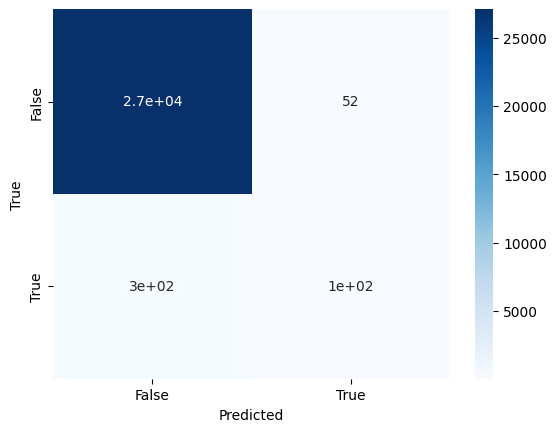

Precision: 0.658
Recall:    0.251
F1 Score:  0.363
Accuracy:  0.987
Clipping 14 genes with -log10(p) > 10


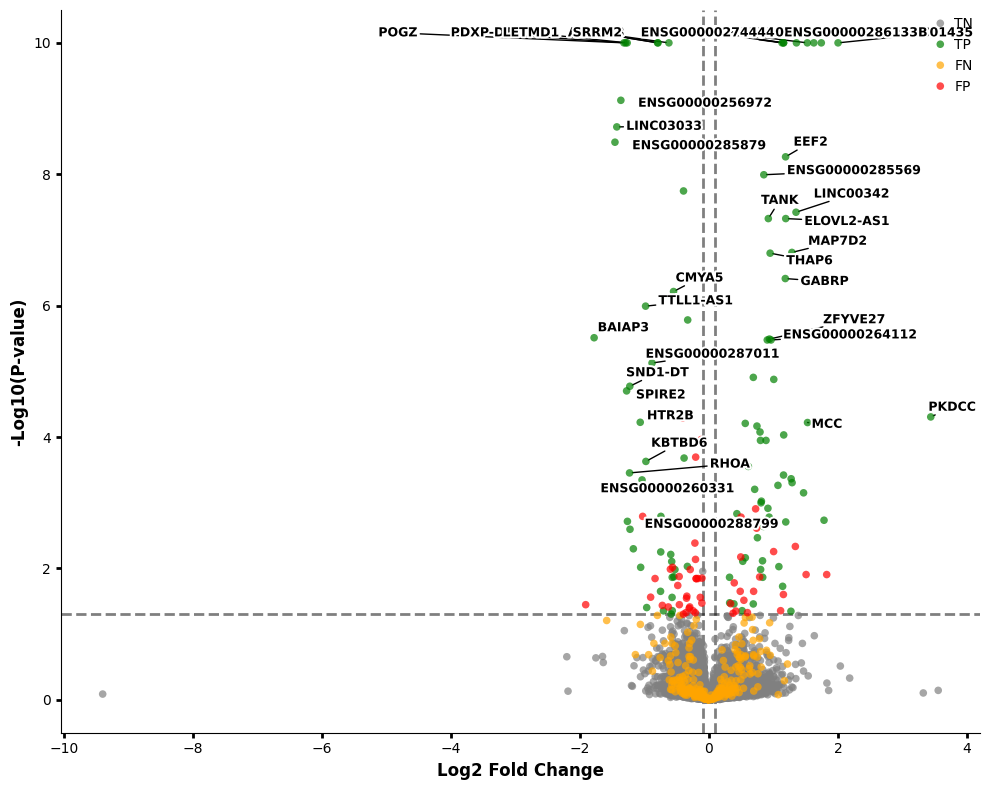

,gene,logFC_case_controlcase,p_case_controlcase,adj_p_case_controlcase,is_significant,is_true_DEG,-log10p,category,sorter
0,A1BG,-0.074118,0.171702,0.785220,False,False,0.105009,TN,-0.007783
1,A1BG-AS1,-0.062690,0.238337,0.820915,False,False,0.085702,TN,-0.005373
2,A1CF,-0.200797,0.099425,0.716977,False,False,0.144495,TN,-0.029014
3,A2M,0.291139,0.135753,0.757702,False,False,0.120501,TN,0.035083
4,A2M-AS1,0.037125,0.577958,0.924243,False,False,0.034214,TN,0.001270
...,...,...,...,...,...,...,...,...,...
27538,ZZEF1,-0.013486,0.621963,0.932995,False,False,0.030121,TN,-0.000406
27539,ZZZ3,0.036144,0.484449,0.902542,False,False,0.044532,TN,0.001610
27540,ENSG00000205653,0.167802,0.796655,0.966762,False,False,0.014680,TN,0.002463
27541,ENSG00000223438,0.268900,0.632085,0.935620,False,False,0.028901,TN,0.007771



#################
dorsal_matrix
#################



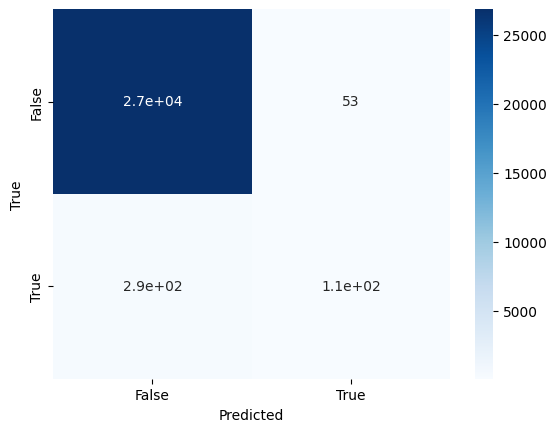

Precision: 0.671
Recall:    0.270
F1 Score:  0.385
Accuracy:  0.987
Clipping 15 genes with -log10(p) > 10


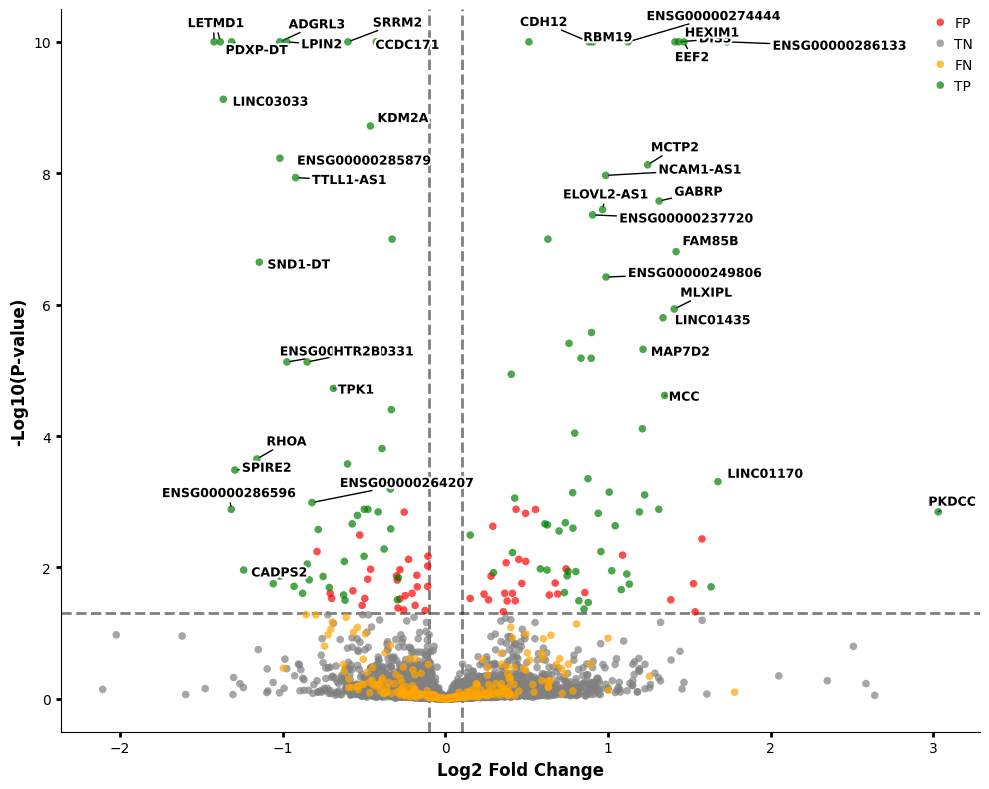

,gene,logFC_case_controlcase,p_case_controlcase,adj_p_case_controlcase,is_significant,is_true_DEG,-log10p,category,sorter
0,A1BG,-0.175406,0.000052,0.013133,True,False,1.881651,FP,-0.330052
1,A1BG-AS1,-0.037076,0.505130,0.922044,False,False,0.035248,TN,-0.001307
2,A1CF,-0.324076,0.002439,0.237925,False,False,0.623559,TN,-0.202081
3,A2M,0.213718,0.223609,0.865291,False,False,0.062838,TN,0.013430
4,A2M-AS1,0.052188,0.401360,0.904141,False,False,0.043764,TN,0.002284
...,...,...,...,...,...,...,...,...,...
27314,ZZEF1,-0.047754,0.084166,0.784488,False,False,0.105414,TN,-0.005034
27315,ZZZ3,0.017314,0.778695,0.966962,False,False,0.014591,TN,0.000253
27316,ENSG00000205653,0.514280,0.431363,0.908616,False,False,0.041620,TN,0.021404
27317,ENSG00000223438,-0.102446,0.876719,0.982292,False,False,0.007759,TN,-0.000795



#################
espn
#################



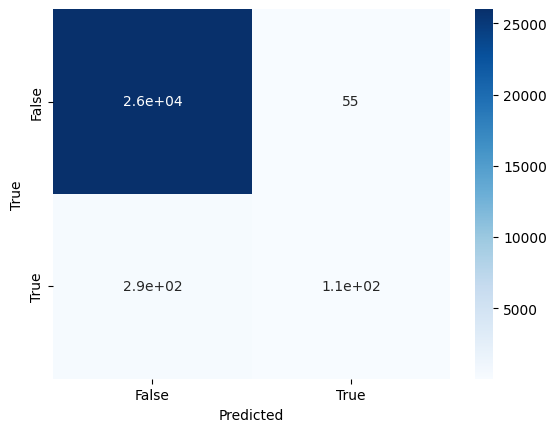

Precision: 0.667
Recall:    0.275
F1 Score:  0.389
Accuracy:  0.987
Clipping 24 genes with -log10(p) > 10


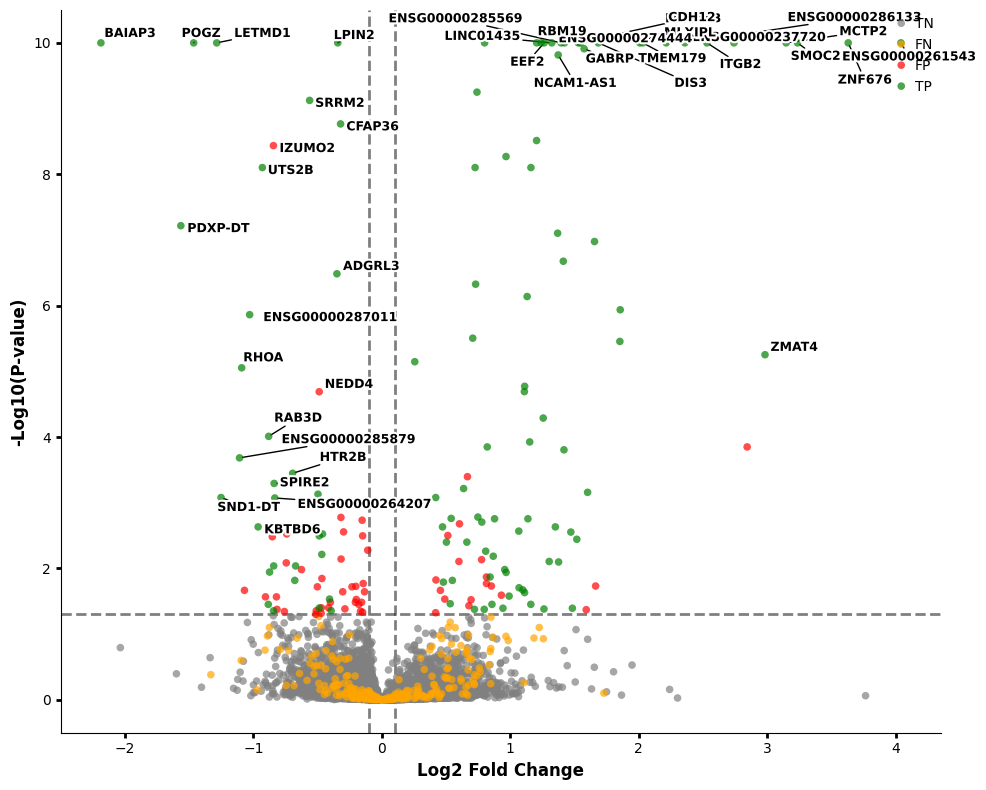

,gene,logFC_case_controlcase,p_case_controlcase,adj_p_case_controlcase,is_significant,is_true_DEG,-log10p,category,sorter
0,A1BG,-0.094929,0.292339,0.897330,False,False,0.047048,TN,-0.004466
1,A1BG-AS1,-0.103560,0.176259,0.832820,False,False,0.079449,TN,-0.008228
2,A1CF,-0.228541,0.302796,0.898909,False,False,0.046284,TN,-0.010578
3,A2M,0.108291,0.856455,0.987127,False,False,0.005627,TN,0.000609
4,A2M-AS1,0.017345,0.729826,0.976422,False,False,0.010362,TN,0.000180
...,...,...,...,...,...,...,...,...,...
26457,ZYX,0.015040,0.810315,0.984069,False,False,0.006974,TN,0.000105
26458,ZZEF1,-0.035080,0.188603,0.839019,False,False,0.076228,TN,-0.002674
26459,ZZZ3,0.006883,0.902928,0.993041,False,False,0.003033,TN,0.000021
26460,ENSG00000223438,-0.423673,0.472614,0.941040,False,False,0.026392,TN,-0.011182



#################
patch
#################



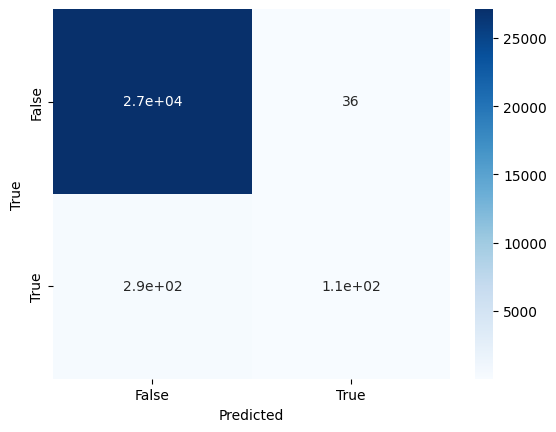

Precision: 0.746
Recall:    0.265
F1 Score:  0.391
Accuracy:  0.988
Clipping 16 genes with -log10(p) > 10


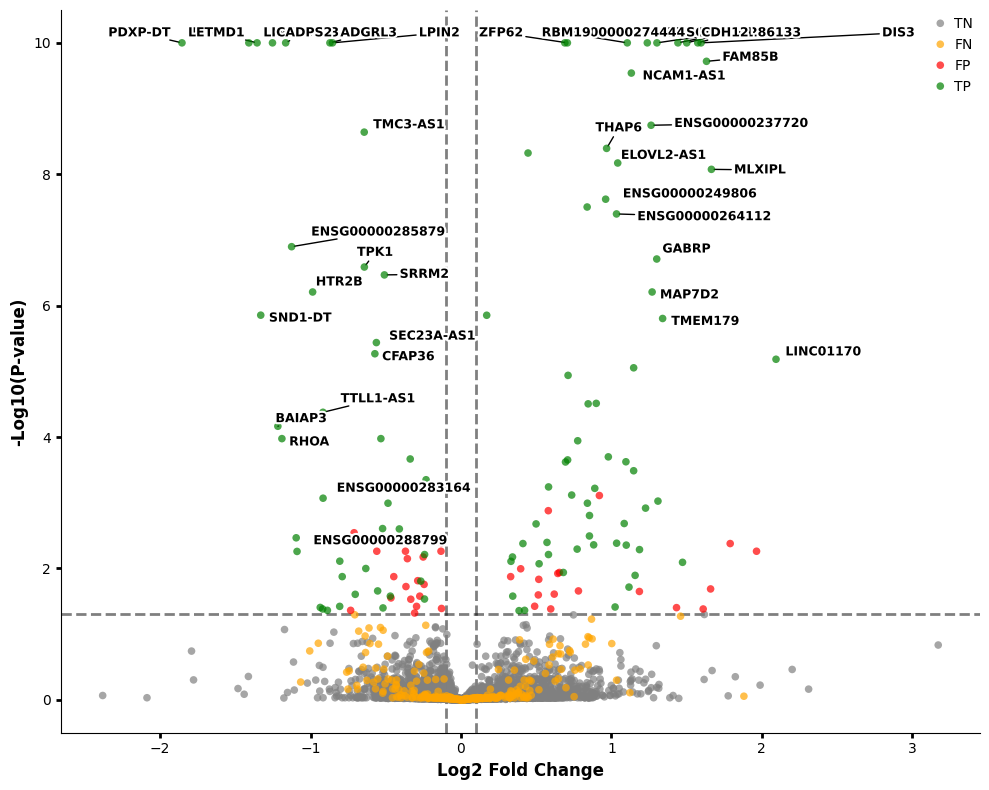

,gene,logFC_case_controlcase,p_case_controlcase,adj_p_case_controlcase,is_significant,is_true_DEG,-log10p,category,sorter
0,A1BG,-0.105620,0.025013,0.686334,False,False,0.163464,TN,-0.017265
1,A1BG-AS1,-0.038748,0.520140,0.948181,False,False,0.023109,TN,-0.000895
2,A1CF,-0.299798,0.011892,0.530177,False,False,0.275579,TN,-0.082618
3,A2M,0.194459,0.465262,0.941826,False,False,0.026029,TN,0.005062
4,A2M-AS1,0.008426,0.899387,0.989300,False,False,0.004672,TN,0.000039
...,...,...,...,...,...,...,...,...,...
27546,ZZEF1,-0.053931,0.048693,0.809678,False,False,0.091688,TN,-0.004945
27547,ZZZ3,0.020508,0.755566,0.971670,False,False,0.012481,TN,0.000256
27548,ENSG00000205653,0.109088,0.856146,0.983507,False,False,0.007223,TN,0.000788
27549,ENSG00000223438,0.360623,0.607771,0.952956,False,False,0.020927,TN,0.007547


In [6]:
for ct in adata.obs[CT_FOR_DEG_VARIABLE].unique():

    print(f"\n#################\n{ct}\n#################\n")

    csv_path = os.path.join(SAVE_FOLDER, f"{ct.replace(' ', '_')}_nebula_results.csv")

    df_nebula = pd.read_csv(csv_path)

    DEG.plot_nebula_results(df_nebula, 
                        df_true_degs, 
                        col_p=f"p_{CONTRAST_VARIABLE}{CONTRAST_STIM}", 
                        col_logFC=f"logFC_{CONTRAST_VARIABLE}{CONTRAST_STIM}", 
                        col_gene="gene",
                        PVAL_THR=PVAL_THR,
                        LOGFC_THR=LOGFC_THR,
                        max_FDR=10,
                        add_adj_p_col=True
                        )
    #break

# Over All Plot

ventral_matrix
dorsal_matrix
espn
patch


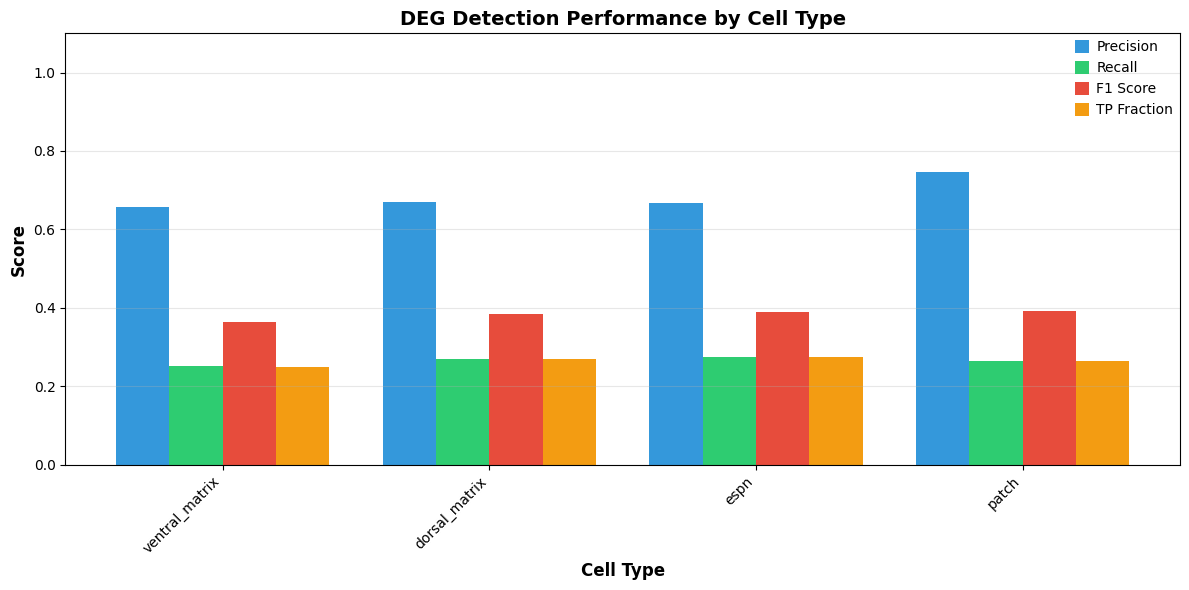


Metrics Summary:
     Cell Type  Precision   Recall       F1  TP Fraction
ventral_matrix   0.657895 0.250627 0.362976        0.250
 dorsal_matrix   0.670807 0.270000 0.385027        0.270
          espn   0.666667 0.275000 0.389381        0.275
         patch   0.746479 0.265000 0.391144        0.265


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

# Collect metrics for all cell types
results = []

for ct in adata.obs[CT_FOR_DEG_VARIABLE].unique():

    print(ct)
    
    # Read CSV
    csv_path = os.path.join(SAVE_FOLDER, f"{ct.replace(' ', '_')}_nebula_results.csv")
    df_nebula = pd.read_csv(csv_path)
        
    # Calculate adjusted p-values
    from statsmodels.stats.multitest import multipletests
    col_p_adj = f"adj_p_{CONTRAST_VARIABLE}{CONTRAST_STIM}"
    df_nebula[col_p_adj] = multipletests(df_nebula[f"p_{CONTRAST_VARIABLE}{CONTRAST_STIM}"], method="fdr_bh")[1]
    
    # Determine significance
    df_nebula["is_significant"] = (
        (df_nebula[col_p_adj] <= PVAL_THR) & 
        (np.abs(df_nebula[f"logFC_{CONTRAST_VARIABLE}{CONTRAST_STIM}"]) >= LOGFC_THR)
    )
    df_nebula["is_true_DEG"] = df_nebula["gene"].isin(df_true_degs["gene_id"])
    
    # Calculate metrics
    precision = precision_score(df_nebula["is_true_DEG"], df_nebula["is_significant"])
    recall = recall_score(df_nebula["is_true_DEG"], df_nebula["is_significant"])
    f1 = f1_score(df_nebula["is_true_DEG"], df_nebula["is_significant"])
    
    # TP fraction
    tp = (df_nebula["is_true_DEG"] & df_nebula["is_significant"]).sum()
    tp_fraction = tp / df_true_degs.shape[0]
    
    results.append({
        'Cell Type': ct,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'TP Fraction': tp_fraction
    })

    #break

# Create dataframe
df_metrics = pd.DataFrame(results)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(df_metrics))
width = 0.2

ax.bar(x - 1.5*width, df_metrics['Precision'], width, label='Precision', color='#3498db')
ax.bar(x - 0.5*width, df_metrics['Recall'], width, label='Recall', color='#2ecc71')
ax.bar(x + 0.5*width, df_metrics['F1'], width, label='F1 Score', color='#e74c3c')
ax.bar(x + 1.5*width, df_metrics['TP Fraction'], width, label='TP Fraction', color='#f39c12')

ax.set_xlabel('Cell Type', fontweight='bold', fontsize=12)
ax.set_ylabel('Score', fontweight='bold', fontsize=12)
ax.set_title('DEG Detection Performance by Cell Type', fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(df_metrics['Cell Type'], rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Display table
print("\nMetrics Summary:")
print(df_metrics.to_string(index=False))



---
---
---

In [ ]:
# for ct in adata.obs[CT_FOR_DEG_VARIABLE].unique():

#     path_qs = f"{QS_TMP_FOLDER}/{ct.replace(' ', '_')}.qs"
#     output_csv = f"{QS_TMP_FOLDER}/{ct.replace(' ', '_')}_nebula_results.csv"

#     print(ct, "\n", path_qs, "\n", output_csv)
    
#     import rpy2.robjects as ro

#     ro.r(f"""
#         library(nebula)
#         library(qs)
#         library(Seurat)
        
#         # Load Seurat object
#         cat("Loading", "{ct}", "...\\n")
#         sobj <- qread("{path_qs}")
        
#         # Extract count matrix (genes x cells) - Seurat v5
#         count_matrix <- GetAssayData(sobj, assay = "RNA", layer = "counts")
#         #count_matrix <- as.matrix(count_matrix)

#         # ========== CRITICAL: FILTER GENES FIRST ==========
#         # Remove genes with very low expression
#         genes_total_counts <- Matrix::rowSums(count_matrix)
#         genes_n_cells <- Matrix::rowSums(count_matrix > 0)
        
#         # Keep only genes with:
#             # - At least 50 cells expressing
#             # - At least 100 total counts across all cells
#         keep_genes <- (genes_n_cells >= 50) & (genes_total_counts >= 100)
#         cat("Genes before filtering:", nrow(count_matrix), "\\n")
#         count_matrix <- count_matrix[keep_genes, ]
#         cat("Genes after filtering:", nrow(count_matrix), "\\n")
        
        
#         # Extract metadata
#         meta <- sobj@meta.data
        
#         # CRITICAL: Ensure factors are properly coded
#         # Convert condition to factor if it isn't already
#         meta${CONTRAST_VARIABLE} <- as.factor(meta${CONTRAST_VARIABLE})
        
#         # Get ID vector (must be factor for NEBULA)
#         id <- as.factor(meta[["{SAMPLE_VARIABLE}"]])
        
#         # Get offset (library size)
#         offset <- meta[["{LIBRARY_SIZE_COL}"]]
        
#         cat("\\nData dimensions:\\n")
#         cat("  Genes:", nrow(count_matrix), "\\n")
#         cat("  Cells:", ncol(count_matrix), "\\n")
#         cat("  Subjects:", length(unique(id)), "\\n")
#         cat("  Condition levels:", levels(meta${CONTRAST_VARIABLE}), "\\n")
        
#         # Build DESIGN MATRIX (not just data frame!)
#         # NEBULA needs model.matrix format with intercept
#         pred_formula <- as.formula("~ {' + '.join([CONTRAST_VARIABLE, *COVARIATES_FOR_DEG])}")
#         pred_matrix <- model.matrix(pred_formula, data = meta)
        
#         cat("\\nPredictor matrix dimensions:", dim(pred_matrix), "\\n")
#         cat("Predictor columns:", colnames(pred_matrix), "\\n")
        
#         # Group cells by subject (recommended for speed and accuracy)
#         # Try to group (reorder) cells by subject
#         data_g <- group_cell(
#             count = count_matrix,
#             id = id,
#             pred = pred_matrix,
#             offset = offset
#         )
        
#         # If NULL, cells already sorted - use original data
#         if (is.null(data_g)) {{
#             cat("Cells already sorted by subject - using original data\\n")
#             data_g <- list(
#                 count = count_matrix,
#                 id = id,
#                 pred = pred_matrix,
#                 offset = offset
#             )
#         }}
                
#         # Run NEBULA with LN method (log-normal)
#         cat("\\nRunning NEBULA LN method...\\n")
#         re <- nebula(
#             count = data_g$count,
#             id = data_g$id,
#             pred = data_g$pred,
#             offset = data_g$offset,
#             method = 'LN', # HL more accurate
#             ncore = 4
#         )
        
#         cat("\\nNEBULA completed!\\n")
        
#         # Extract summary
#         summary_df <- re$summary
        
#         cat("Result columns:", colnames(summary_df), "\\n")
#         cat("Number of genes tested:", nrow(summary_df), "\\n")
        
#         # Save full results
#         write.csv(summary_df, "{output_csv}", row.names = FALSE, quote = FALSE)
#         cat("Saved results to {output_csv}\\n")
        
#         # Print summary statistics
#         if ("{CONTRAST_VARIABLE}" %in% colnames(summary_df)) {{
#             sig_genes <- sum(summary_df$p_{CONTRAST_VARIABLE} < 0.05, na.rm = TRUE)
#             cat("Significant genes (p < 0.05):", sig_genes, "\\n")
#         }}

#         rm(sobj, count_matrix, meta, data_g, re)
#         gc()
#     """)
    
#     print(f"✓ Completed {ct}\n")
    
#     break